## LAB1
## SIMULATION OF CHEMICAL REACTION

## OBJECTIVE
### To simulate chemical reactions using python


## THEORY
#### Simulation and modeling are techniques used to study the behavior of real systems using mathematical models. In chemical reaction simulation, mathematical equations are used to predict how reactant and product concentrations change with time.
#### Chemical reactions are examples of continuous systems, where variables such as concentration and temperature vary continuously over time. Continuous systems are generally described using differential equations.
#### 1.Ordinary Differential Equations (ODEs) contain derivatives with respect to a single independent variable, usually time. They are used when system variables depend only on time. Many chemical reaction kinetics models are represented using ODEs.
#### 2.Partial Differential Equations (PDEs) contain derivatives with respect to more than one independent variable, such as time and position. PDEs are used when variables change with both time and space, such as in heat transfer, diffusion, and reaction-diffusion processes.
#### Simulation of chemical reactions helps engineers analyze reaction behavior, predict system performance, optimize operating conditions, and reduce the need for costly experiments. Applications include reactor design, process control, heat and mass transfer analysis, and process optimization in various engineering fields.
### Applications
#### 1.Engineering and Manufacturing
#### 2.Healthcare and Medicine
#### 3.Business and Economics
#### 4.Environmental Science
#### 5.Defense and Military
#### 6.Education and Training

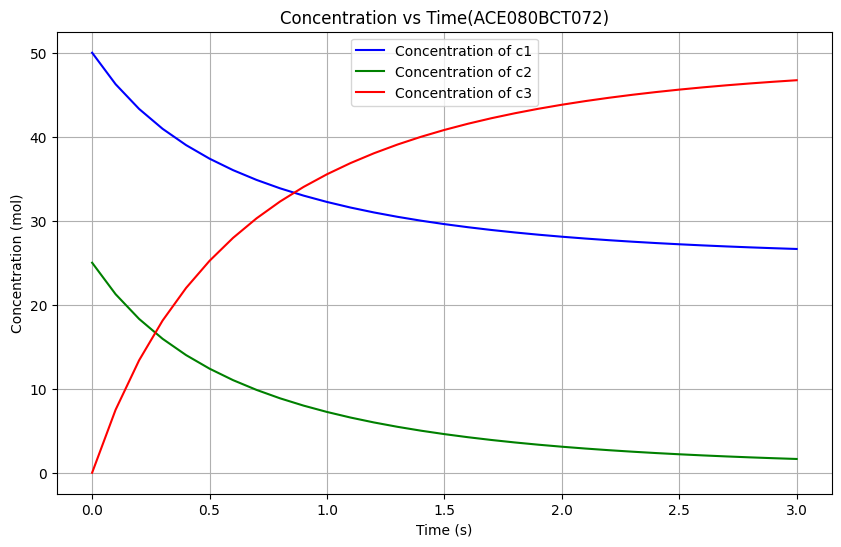

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k1 = 0.03
k2 = 0.01
dt = 0.1
steps = 30
# Initial concentrations
c1 = [50.0] # Reactant A
c2 = [25.0] # Reactant B
c3 = [0.0] # Product C 
# Open a file to write the results
with open("output.txt", "w") as file:
 # Write initial concentrations
 file.write(f"{c1[0]} {c2[0]} {c3[0]}\n")

 # Time-stepping loop for concentration updates
 for i in range(steps):
    # Calculate next concentrations based on the given equations
    c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

    # Append the new concentrations to the lists
    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

 # Write concentrations to the file
 file.write(f"{c1_next} {c2_next} {c3_next}\n")
# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, c1, label='Concentration of c1', color='blue')
plt.plot(time_points, c2, label='Concentration of c2', color='green')
plt.plot(time_points, c3, label='Concentration of c3', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('Concentration vs Time(ACE080BCT072)')
plt.legend()
plt.grid(True)
plt.show()


## Reaction 1

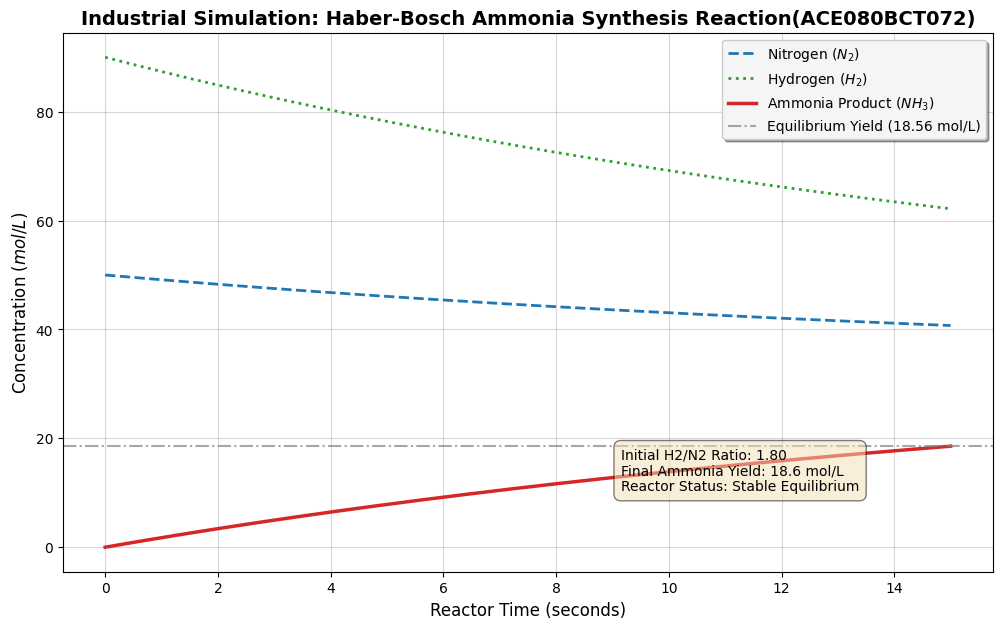

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- REAL USE CASE PARAMETERS ---
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002  # Forward rate constant (scaled for this simulation)
k_b = 0.005   # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [50.0]    # Nitrogen
H2 = [90.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]^3
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction(ACE080BCT072)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor='#f5f5f5')
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()

## Reaction 2

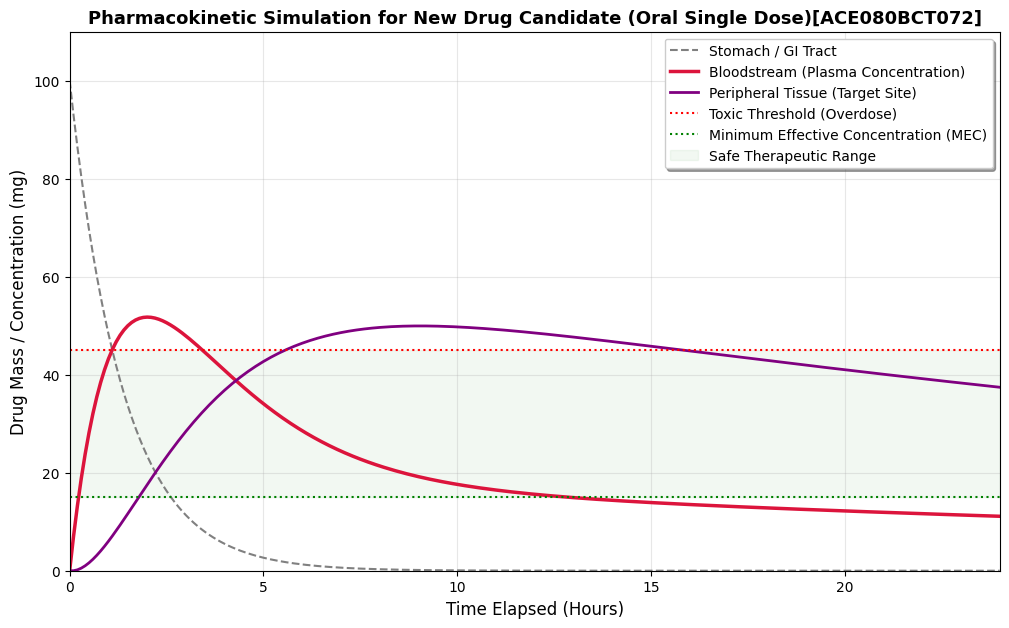

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# --- CLINICAL PARAMETERS ---
ka = 0.7    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.26   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.1   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1    # Time steps in hours
steps = 240 # Simulate for 24 hours

# Initial states (assuming an oral dose of 100mg at t=0)
stomach = [100.0]      # Drug starting in the GI tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Organs/Fat)

# Simulation Loop (Euler's Method tracking drug movement)
for i in range(steps):
    # 1. Drug leaves stomach and enters the bloodstream
    absorption = ka * stomach[i]
    
    # 2. Drug moves back and forth between bloodstream and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Liver/Kidneys filter the drug out of the bloodstream
    elimination = ke * bloodstream[i]
    
    # Differential changes per time step
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis converted to hours
time_hours = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Define medical thresholds (Therapeutic Window)
plt.axhline(y=45, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=15, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 15, 45, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Graph styling
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose)[ACE080BCT072]', fontsize=13, fontweight='bold')
plt.xlim(0, 24)
plt.ylim(0, 110)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

## Reaction 3


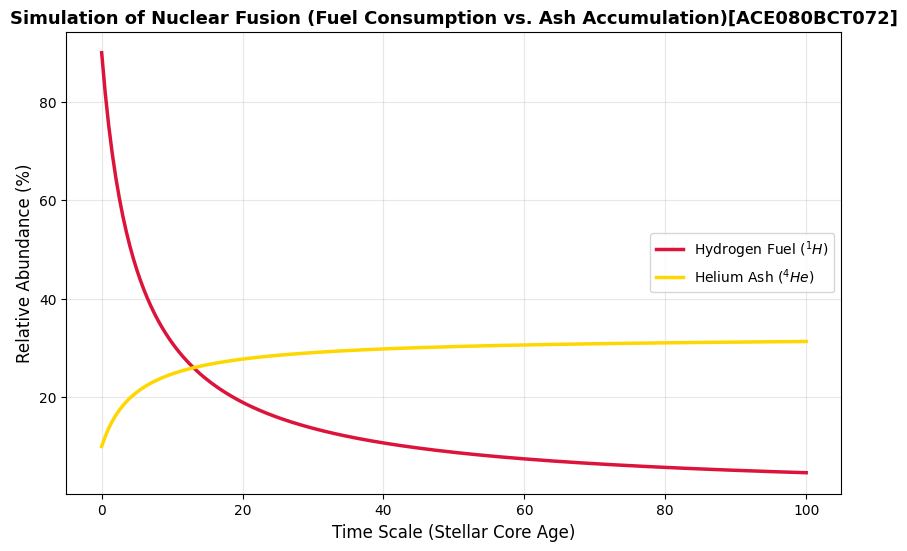

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005  
dt = 0.5            # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [90.0]  # Start with 100% Hydrogen fuel
helium = [10.0]      # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model 
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation)[ACE080BCT072]', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

## Discussion and Conclusion

The simulations successfully modeled concentration changes over time using Eulers method to numerically solve ODEs in Python.Across all reactions, the results followed expected trends i.e. reactants depleted as products formed,with systems approaching equilibrium or a stable end state. Rate constants and stoichiometric ratios directly influenced the speed and extent of each reaction.Negative concentration clamping was applied where needed to handle numerical overshoot inherent to discrete time stepping.The plots provided clear visual confirmation of the simulated dynamics in each case.

Python with mumPy and matplotlib proved effective for modeling diverse chemical and biological systems via numerical ODE integration. All four simulations correctly reproduced expected concentration time behaviors,reversible equilibrium, industrial synthesis yield, drug pharmacokinetics, and stellar fuel depletion. The lab confirms that even simplified Euler-method models capture meaningful real-world dynamics when rate constants and stoichiometry are correctly applied.